## Initialize Spark Session

In [1]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .appName("Clusters_amritap1")
    .config("spark.driver.memory", "10g")
    .config("spark.executor.memory", "10g")
    .config("spark.executor.cores", "1")
    .config("spark.executor.instances", "14")
    .config("spark.serializer","org.apache.spark.serializer.KryoSerializer")
    .config("spark.kryoserializer.buffer","1g")
    .config("spark.driver.maxResultSize","8g")
    .getOrCreate()
)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/12/12 15:09:47 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## Load Raw Data

In [9]:
commentsDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/final_data_with_id/comments")

In [10]:
submissionsDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/final_data_with_id/submissions")

In [11]:
commentsDF.printSchema()

root
 |-- id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- author_created_utc: long (nullable = true)
 |-- author_flair_text: string (nullable = true)
 |-- body: string (nullable = true)
 |-- controversiality: long (nullable = true)
 |-- created_utc: long (nullable = true)
 |-- is_submitter: boolean (nullable = true)
 |-- score: long (nullable = true)



In [12]:
submissionsDF.printSchema()

root
 |-- id: string (nullable = true)
 |-- author: string (nullable = true)
 |-- created_utc: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- score: long (nullable = true)
 |-- selftext: string (nullable = true)
 |-- title: string (nullable = true)



## Data Cleaning

I implemented a two-step cleaning process:
1. **Remove bot accounts** - Filter out automoderator, bot, and moderator accounts
2. **Remove deleted content** - Drop `[deleted]` and `[removed]` posts

Keeping bots would artificially inflate certain ticker associations (e.g., automated stock updates), making the patterns less meaningful for understanding organic user discussions.

In [13]:
from pyspark.sql import functions as F

def remove_bot_accounts(df):
    a = F.lower(F.col("author"))
    is_bot = F.coalesce(
        a.contains("automoderator") | a.contains("moderator") | a.contains("bot") | a.contains("automod"),
        F.lit(False)
    )
    df = df.filter(~is_bot)
    return df

In [14]:
commentsDF = remove_bot_accounts(commentsDF)
submissionsDF = remove_bot_accounts(submissionsDF)

In [15]:
from pyspark.sql import functions as F

def remove_deleted_content(df, text_column):
    df = df.filter(
        F.col(text_column).isNotNull() &
        ~F.col(text_column).isin("[deleted]", "[removed]")
    )
    return df

In [16]:
commentsDF = remove_deleted_content(commentsDF, 'body')
submissionsDF = remove_deleted_content(submissionsDF, 'selftext')

## Data Preparation

### Text Cleaning
Clean text by:
- Converting HTML
- Removing URLs and markdown links
- Avoid multiple whitespaces
- Removing zero-width characters
- Converting to lowercase

### Removing Stopwords
Using default English stopwords plus domain-specific terms like "reddit", "wsb", "wallstreetbets" that appear frequently but don't distinguish topics. Keeping ticker symbols and financial terms intact.

### Process Submissions and Comments
- Convert timestamps to datetime format
- Filter by date range and valid authors
- Concatenate title + selftext for submissions and body for comments for the entire text
- Add document metadata

In [17]:
t0  = F.to_timestamp(F.lit("2020-01-01"))
t1  = F.to_timestamp(F.lit("2022-12-31 23:59:59"))

In [18]:
@F.udf("string")
def clean_text(s):
    if not s: return None
    import re
    s = re.sub(r"&amp;","&", s)
    s = re.sub(r"\[.*?\]\(https?://\S+\)"," ", s)
    s = re.sub(r"https?://\S+"," ", s)
    s = re.sub(r"[^\S\r\n]+"," ", s)
    s = re.sub(r"[\u200b-\u200d\uFEFF]","", s)
    return s.strip().lower()

In [19]:
from pyspark.sql import functions as F, types as T
from pyspark.ml.feature import RegexTokenizer, StopWordsRemover

In [20]:
extra_stops = ["amp","reddit","wsb","wallstreetbets","rt","tl;dr","edit"]
base_stops = StopWordsRemover.loadDefaultStopWords("english")
stopwords = list(set(base_stops + extra_stops))

In [21]:
posts = (submissionsDF
  .withColumn("created_ts",F.to_timestamp(F.col("created_utc")))
  .filter((F.col("created_ts")>=t0) & (F.col("created_ts")<=t1))
  .filter(~F.lower(F.col("author")).isin("[deleted]","[removed]"))
  .withColumn("raw_text", F.concat_ws(" ", F.col("title"), F.col("selftext")))
  .filter(F.col("raw_text").isNotNull() & (F.length("raw_text")>0))
  .withColumn("text", clean_text("raw_text"))
  .select(
      F.col("id").alias("doc_id"),
      F.lit("post").alias("doc_type"),
      "author","created_ts","score","num_comments","text"
  )
  .dropDuplicates(["doc_id"])
)

In [22]:
comments = (commentsDF
  .withColumn("created_ts",F.to_timestamp(F.col("created_utc")))
  .filter((F.col("created_ts")>=t0) & (F.col("created_ts")<=t1))
  .filter(~F.lower(F.col("author")).isin("[deleted]","[removed]"))
  .filter(~F.lower(F.col("body")).isin("[deleted]","[removed]"))
  .withColumn("text", clean_text("body"))
  .select(
      F.col("id").alias("doc_id"),
      F.lit("comment").alias("doc_type"),
      "author","created_ts","score",
      F.lit(None).cast("long").alias("num_comments"),
      "text"
  )
  .dropDuplicates(["doc_id"])
)

In [23]:
docs = posts.unionByName(comments)

### Add Temporal Features
Adding year, quarter, month, and months_since_start for time-series analysis.

Filter out very short texts (< 5 chars).

In [24]:
docs = (docs
  .withColumn("year", F.year("created_ts"))
  .withColumn("quarter", F.quarter("created_ts"))
  .withColumn("month", F.month("created_ts"))
  .withColumn("months_since_start",
              F.round(F.months_between(F.col("created_ts"), F.to_timestamp(F.lit("2014-01-01"))), 1))
  .filter(F.col("text").isNotNull() & (F.length("text") >= 5))
)

### Tokenization and Stopword Removal
Using regex tokenizer to extract:
- Ticker symbols (e.g., $AAPL)
- Words with 2+ letters
- Handling hyphens and apostrophes in words

Then removing stopwords to focus on terms with contents.

In [25]:
tokenizer = RegexTokenizer(
    inputCol="text",
    outputCol="tokens",
    pattern=r"(?u)(?:\$?[A-Za-z]{2,5}|[A-Za-z][\w'-]{2,})",
    gaps=False,              
    toLowercase=True
)
tok_temp = tokenizer.transform(docs)

tok_temp = tok_temp.withColumn(
    "tokens_clean_temp",
    F.expr("""filter(tokens, x -> x rlike '(?i)^(\\$[A-Z]{2,5}|[a-z]{3,}([\\'-][a-z]+)*)$')""")
)
remover   = StopWordsRemover(inputCol="tokens_clean_temp", outputCol="tokens_clean", stopWords=stopwords)
tok = remover.transform(tok_temp)

### Final Filtering
Ensure at least 3 tokens per document to ensure sufficient content.

In [26]:
cleanDF = (tok
  .withColumn("tok_len", F.size("tokens_clean"))
  .filter(F.col("tok_len") >= 3)
  .drop("tok_len")
)

## TF-IDF Vectorization

In [26]:
from pyspark.ml.feature import CountVectorizer, IDF

cv = CountVectorizer(
    inputCol="tokens_clean",
    outputCol="termFreq",
    vocabSize=1000,
    minDF=50,
    binary=False
)
cv_model = cv.fit(cleanDF)
tfDF = cv_model.transform(cleanDF)

In [27]:
cv_model.write().overwrite().save("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/cv_model")

In [23]:
idf = IDF(inputCol="termFreq", outputCol="features_tfidf")
idf_model = idf.fit(tfDF)
tfidfDF = idf_model.transform(tfDF).select(
    "doc_id","doc_type","author","created_ts","year","quarter","month","months_since_start",
    "score","num_comments","features_tfidf"
)

In [24]:
print("Vocab size:", len(cv_model.vocabulary))
tfidfDF.show(3, truncate=False)

Vocab size: 1000


[Stage 19:=====================================================>  (51 + 2) / 53]

+-------+--------+--------------------+-------------------+----+-------+-----+------------------+-----+------------+---------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|doc_id |doc_type|author              |created_ts         |year|quarter|month|months_since_start|score|num_comments|features_tfidf                                                                                                                                   

In [25]:
tfidfDF.write.mode("overwrite").parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/tfidf_data")

## Principal Component Analysis (PCA)

In [26]:
from pyspark.ml.feature import PCA
pca = PCA(k=20, inputCol="features_tfidf", outputCol="pcaFeatures")
pca_model = pca.fit(tfidfDF)
pcaDF = pca_model.transform(tfidfDF)

25/12/11 21:39:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
25/12/11 21:39:15 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS
25/12/11 22:24:27 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK


In [27]:
pcaDF.write.mode("overwrite").parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/pca_data")

In [28]:
explained = pca_model.explainedVariance.toArray()
print("Explained variance (first 10 comps):", explained[:10])
print("Total variance captured:", explained.sum())

Explained variance (first 10 comps): [0.18609109 0.12313737 0.08192871 0.04948916 0.04221803 0.03087259
 0.02098247 0.01997898 0.0103606  0.00964297]
Total variance captured: 0.6253012581630445


In [29]:
pcaDF.select("doc_id","year","months_since_start","pcaFeatures").show(3, truncate=False)

[Stage 53:======================================================> (52 + 1) / 53]

+-------+----+------------------+--------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|doc_id |year|months_since_start|pcaFeatures                                                                                                                                                                                                                                                                                                                                                                                                                                 |
+-------+----+------------------+-----------------------------------------

In [2]:
pcaDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/pca_data")

In [38]:
# Check the actual distribution of PCA features
import numpy as np

sample_pca = pcaDF.sample(fraction=0.001, seed=42).select("pcaFeatures").collect()
sample_arrays = np.array([row.pcaFeatures.toArray() for row in sample_pca])

print("PCA feature statistics (sample of 0.1%):")
print(f"  Shape: {sample_arrays.shape}")
print(f"  Mean per component: {sample_arrays.mean(axis=0)[:5]}")
print(f"  Std per component: {sample_arrays.std(axis=0)[:5]}")
print(f"  Min per component: {sample_arrays.min(axis=0)[:5]}")
print(f"  Max per component: {sample_arrays.max(axis=0)[:5]}")

# Check if features need scaling
print(f"\nFeature scale ranges vary: {sample_arrays.std(axis=0).min():.4f} to {sample_arrays.std(axis=0).max():.4f}")

PCA feature statistics (sample of 0.1%):
  Shape: (38736, 20)
  Mean per component: [ 0.01873294 -0.01492047 -0.05512139  0.03589675  0.01750937]
  Std per component: [2.31709614 0.29366932 0.59109703 6.67551694 0.38009136]
  Min per component: [-5.50862201e-02 -6.23851619e+00 -5.41628349e+01 -1.82720548e-01
 -1.56091952e-02]
  Max per component: [4.41291679e+02 1.80647909e-02 8.14678241e-02 1.31349356e+03
 3.54213933e+01]

Feature scale ranges vary: 0.2841 to 6.6755


## K-Means Clustering

In [3]:
from pyspark.ml.feature import StandardScaler

# Standardize PCA features before clustering
scaler = StandardScaler(inputCol="pcaFeatures", outputCol="scaledFeatures", withMean=True, withStd=True)
scaler_model = scaler.fit(pcaDF)
scaledDF = scaler_model.transform(pcaDF)

print("Features standardized. Ready for clustering.")

Features standardized. Ready for clustering.


In [6]:
scaledDF.write.mode("overwrite").parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/scaled_data")

25/12/12 04:28:45 WARN MemoryStore: Not enough space to cache rdd_35_71 in memory! (computed 7.9 MiB so far)
25/12/12 04:28:45 WARN MemoryStore: Not enough space to cache rdd_35_74 in memory! (computed 3.5 MiB so far)
25/12/12 04:28:45 WARN MemoryStore: Not enough space to cache rdd_35_69 in memory! (computed 27.0 MiB so far)
25/12/12 04:28:45 WARN MemoryStore: Not enough space to cache rdd_35_73 in memory! (computed 7.9 MiB so far)
25/12/12 04:28:45 WARN MemoryStore: Not enough space to cache rdd_35_72 in memory! (computed 18.0 MiB so far)
25/12/12 04:28:46 WARN MemoryStore: Not enough space to cache rdd_35_73 in memory! (computed 18.0 MiB so far)
25/12/12 04:28:46 WARN MemoryStore: Not enough space to cache rdd_35_71 in memory! (computed 12.0 MiB so far)
25/12/12 04:28:46 WARN MemoryStore: Not enough space to cache rdd_35_74 in memory! (computed 27.0 MiB so far)
25/12/12 04:28:46 WARN MemoryStore: Not enough space to cache rdd_35_75 in memory! (computed 18.0 MiB so far)
25/12/12 04:2

In [40]:
# from pyspark.ml.clustering import KMeans
# from pyspark.ml.evaluation import ClusteringEvaluator

# K = range(2, 11)
# cost = []

# for k in K:
#     km = KMeans(k=k, seed=42, featuresCol="pcaFeatures", predictionCol="cluster")
#     model = km.fit(pcaDF)
#     cost.append(model.summary.trainingCost)
#     pred = model.transform(pcaDF)
#     evalr = ClusteringEvaluator(featuresCol="pcaFeatures", predictionCol="cluster",
#                                 metricName="silhouette", distanceMeasure="squaredEuclidean")
#     score = evalr.evaluate(pred)
#     print(f"k={k}, silhouette={score:.4f}")

In [41]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

sampled_scaledDF = scaledDF.sample(fraction=0.1, seed=42).cache()
K = range(2, 16)
cost = []
silhouette_scores = []

for k in K:
    km = KMeans(k=k, seed=42, featuresCol="scaledFeatures", predictionCol="cluster")
    model = km.fit(sampled_scaledDF)
    inertia = model.summary.trainingCost
    cost.append(inertia)
    pred = model.transform(sampled_scaledDF)
    evalr = ClusteringEvaluator(featuresCol="scaledFeatures", predictionCol="cluster",
                                metricName="silhouette", distanceMeasure="squaredEuclidean")
    score = evalr.evaluate(pred)
    silhouette_scores.append(score)
    print(f"k={k}, inertia={inertia:.2f}, silhouette={score:.4f}")

k=2, inertia=54984709.88, silhouette=1.0000


k=3, inertia=48653678.45, silhouette=1.0000


k=4, inertia=48374700.26, silhouette=1.0000


k=5, inertia=49563650.80, silhouette=0.9734


k=6, inertia=43705317.26, silhouette=0.9802


...

k=12, inertia=28502293.48, silhouette=0.8223


k=13, inertia=26253913.52, silhouette=0.7370


k=14, inertia=26084822.12, silhouette=0.6936


[Stage 1427:===================================================>(100 + 1) / 101]

k=15, inertia=23203613.92, silhouette=0.8321


Evaluating on the full dataset is computationally very expensive. Using a sample is statistically valid for recognising the pattern in the elbow method.

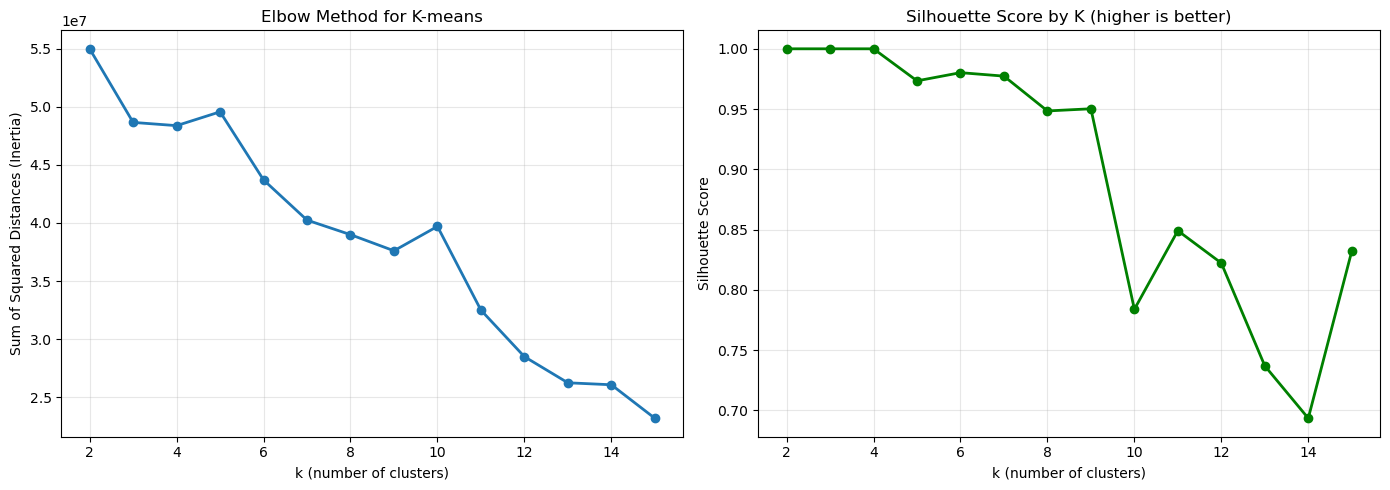

In [42]:
import matplotlib.pyplot as plt

# Create side-by-side plots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Elbow plot
ax1.plot(K, cost, 'o-', linewidth=2)
ax1.set_xlabel('k (number of clusters)')
ax1.set_ylabel('Sum of Squared Distances (Inertia)')
ax1.set_title('Elbow Method for K-means')
ax1.grid(True, alpha=0.3)

# Silhouette plot
ax2.plot(K, silhouette_scores, 'o-', linewidth=2, color='green')
ax2.set_xlabel('k (number of clusters)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Score by K (higher is better)')
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [2]:
pcaDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/pca_data").persist()
pcaDF.count()

25/12/12 13:59:06 WARN MemoryStore: Not enough space to cache rdd_6_32 in memory! (computed 122.6 MiB so far)
25/12/12 13:59:06 WARN BlockManager: Persisting block rdd_6_32 to disk instead.
25/12/12 13:59:06 WARN MemoryStore: Not enough space to cache rdd_6_38 in memory! (computed 63.0 MiB so far)
25/12/12 13:59:06 WARN BlockManager: Persisting block rdd_6_38 to disk instead.
25/12/12 13:59:06 WARN MemoryStore: Not enough space to cache rdd_6_35 in memory! (computed 122.6 MiB so far)
25/12/12 13:59:06 WARN BlockManager: Persisting block rdd_6_35 to disk instead.
25/12/12 13:59:07 WARN MemoryStore: Not enough space to cache rdd_6_32 in memory! (computed 63.0 MiB so far)
25/12/12 13:59:07 WARN MemoryStore: Not enough space to cache rdd_6_35 in memory! (computed 63.0 MiB so far)
25/12/12 13:59:07 WARN MemoryStore: Not enough space to cache rdd_6_40 in memory! (computed 63.0 MiB so far)
25/12/12 13:59:07 WARN BlockManager: Persisting block rdd_6_40 to disk instead.
25/12/12 13:59:08 WARN M

39127649

In [5]:
from pyspark.ml.clustering import KMeans

bestK = 6
kmeans = KMeans(k=bestK, seed=42, featuresCol="pcaFeatures", predictionCol="cluster")
kModel = kmeans.fit(pcaDF)
clusteredDF = kModel.transform(pcaDF)

# Show cluster distribution
print("\nCluster distribution:")
clusteredDF.groupBy("cluster").count().orderBy("cluster").show()

25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_32 in memory! (computed 122.6 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_35 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_38 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_40 in memory! (computed 122.6 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_42 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_43 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_41 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_44 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06 WARN MemoryStore: Not enough space to cache rdd_6_45 in memory! (computed 63.0 MiB so far)
25/12/12 14:00:06


Cluster distribution:


25/12/12 14:02:54 WARN MemoryStore: Not enough space to cache rdd_6_6 in memory! (computed 122.6 MiB so far)
25/12/12 14:02:54 WARN MemoryStore: Not enough space to cache rdd_6_4 in memory! (computed 122.6 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_13 in memory! (computed 63.0 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_16 in memory! (computed 3.7 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_15 in memory! (computed 63.0 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_11 in memory! (computed 122.6 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_14 in memory! (computed 122.6 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_21 in memory! (computed 63.0 MiB so far)
25/12/12 14:02:55 WARN MemoryStore: Not enough space to cache rdd_6_22 in memory! (computed 63.0 MiB so far)
25/12/12 14:02:55 

+-------+--------+
|cluster|   count|
+-------+--------+
|      0|39127027|
|      1|     103|
|      2|      34|
|      3|     439|
|      4|      23|
|      5|      23|
+-------+--------+



In [6]:
clusteredDF.write.mode("overwrite").parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/clustered_data")

25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_3 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_7 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_4 in memory! (computed 122.6 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_5 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_6 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_1 in memory! (computed 122.6 MiB so far)
25/12/12 14:03:00 WARN MemoryStore: Not enough space to cache rdd_6_0 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:05 WARN MemoryStore: Not enough space to cache rdd_6_14 in memory! (computed 63.0 MiB so far)
25/12/12 14:03:05 WARN MemoryStore: Not enough space to cache rdd_6_13 in memory! (computed 122.6 MiB so far)
25/12/12 14:03:05 WARN 

## Cluster Characterization

### Cluster Statistics
Examining cluster sizes and average metrics to understand what differentiates the clusters.

In [7]:
from pyspark.sql import functions as F

clusteredDF.groupBy("cluster").agg(
    F.count("*").alias("count"),
    F.avg("score").alias("avg_score"),
    F.avg("num_comments").alias("avg_comments"),
    F.avg("months_since_start").alias("avg_months")
).orderBy("cluster").show()

25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_6 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_1 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_7 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_0 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_4 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_3 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:37 WARN MemoryStore: Not enough space to cache rdd_6_9 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:38 WARN MemoryStore: Not enough space to cache rdd_6_13 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:38 WARN MemoryStore: Not enough space to cache rdd_6_14 in memory! (computed 63.0 MiB so far)
25/12/12 14:04:38 WARN Mem

+-------+--------+------------------+------------------+-----------------+
|cluster|   count|         avg_score|      avg_comments|       avg_months|
+-------+--------+------------------+------------------+-----------------+
|      0|39127027| 11.80919756566222|61.463994293270495|88.19393809810859|
|      1|     103|18.679611650485437|              44.0|85.40194174757276|
|      2|      34|2.2941176470588234|              NULL|76.09411764705878|
|      3|     439|2.0341685649202734|               0.0|76.23211845102502|
|      4|      23|              26.0|20.043478260869566|75.67391304347828|
|      5|      23|               1.0|              NULL|75.59999999999997|
+-------+--------+------------------+------------------+-----------------+



## Interpretation: Cluster Distribution (2020–2022)

Cluster membership is **extremely imbalanced**: Cluster 0 contains **39,127,027** documents, while all other clusters are tiny by comparison (e.g., Cluster 3 has **439**, Cluster 1 has **103**, and Clusters 4–5 have **23** each). 

This suggests the model is capturing one **dominant “general WSB discourse” mode** (Cluster 0), while the smaller clusters behave more like **niche/edge cases** (e.g., specific tickers, thread-structure artifacts, or rare lexical patterns).

Because the minority clusters are so small, interpretations of those clusters should be treated as **illustrative** rather than representative of the overall corpus.


### Top Terms Per Cluster
Extracting the 15 highest-weighted terms reveals the themes of the content that defines each cluster.

In [2]:
clusteredDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/clustered_data")

In [3]:
tfidfDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/tfidf_data")

In [4]:
from pyspark.ml.feature import CountVectorizerModel
cv_model = CountVectorizerModel.load("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/cv_model")

In [6]:
from pyspark.ml.stat import Summarizer
from pyspark.sql import functions as F
import numpy as np
import pandas as pd

joined = tfidfDF.join(clusteredDF.select("doc_id","cluster"), "doc_id")

# Calculate mean TF-IDF vector per cluster
s = Summarizer.metrics("mean")
cluster_means = (joined.groupBy("cluster")
                 .agg(s.summary(F.col("features_tfidf")).alias("summ"))
                 .select("cluster", F.col("summ.mean").alias("avg_vec"))
                 .orderBy("cluster")
                 .collect())

vocab = cv_model.vocabulary
vocab_size = len(vocab)

# Convert to numpy array for easier manipulation
cluster_vectors = {}
for row in cluster_means:
    cluster_vectors[row['cluster']] = row['avg_vec'].toArray()

# Calculate overall mean (for comparison)
overall_mean = np.mean(list(cluster_vectors.values()), axis=0)

top_n = 15

print("=" * 80)
print("DISTINCTIVE TERMS PER CLUSTER")
print("=" * 80)

for cluster_id in sorted(cluster_vectors.keys()):
    arr = cluster_vectors[cluster_id]
    
    # Calculate difference from overall mean to find distinctive terms
    diff = arr - overall_mean
    
    # Get top terms by this difference (most distinctive)
    idxs = np.argsort(diff)[-top_n:][::-1]
    terms = [(vocab[i], f"{diff[i]:.4f}") for i in idxs]
    
    print(f"\nCluster {cluster_id}:")
    print("  Top distinctive terms (term: distinctiveness score):")
    for term, score in terms:
        print(f"    {term:20s} {score}")
        
print("\n" + "=" * 80)

DISTINCTIVE TERMS PER CLUSTER

Cluster 0:
  Top distinctive terms (term: distinctiveness score):
    emote                0.0762
    img                  0.0657
    also                 0.0631
    yeah                 0.0576
    didn                 0.0568
    submi                0.0446
    yes                  0.0440
    isn                  0.0437
    vote                 0.0395
    tly                  0.0381
    feel                 0.0341
    eithe                0.0325
    means                0.0297
    far                  0.0282
    whole                0.0281

Cluster 1:
  Top distinctive terms (term: distinctiveness score):
    amzn                 3857.0664
    came                 0.0898
    tted                 0.0458
    tho                  0.0400
    reddi                0.0377
    pltr                 0.0352
    feel                 0.0261
    also                 0.0179
    artic                0.0027
    ually                -0.0023
    flair                -0.0023

## Interpretation: Distinctive Terms (What makes clusters different)

The “distinctive terms” output highlights which tokens are **uniquely overrepresented** in each cluster relative to the full corpus.

- **Cluster 0** is dominated by broad conversational / meta language (e.g., *emote, img, yeah, didn, vote, feel*), consistent with it functioning as the main “background” discourse cluster.
- Several small clusters appear to be anchored by **single high-signal identifiers** (e.g., Cluster 1 includes **amzn** with a very large distinctiveness score; Cluster 5 includes **tsla** with a very large distinctiveness score), suggesting **ticker-centric micro-communities** rather than broad behavioral archetypes.
- Cluster 4 is dominated by subreddit infrastructure and thread vocabulary (*walls, bets, daily, threa, discu*), indicating a **daily-thread / discussion-thread** style cluster rather than a market-theme cluster.

Overall, the clusters separate strongly by **format and ticker anchors**, not just semantic topics, which matters when mapping them to behavioral archetypes.

### Cluster Evolution Over Time
Tracking how cluster prevalence changes from 2020-2022. This reveals:
- How and what topics became more/less popular over time
- Major events that might have shifted discussion themes

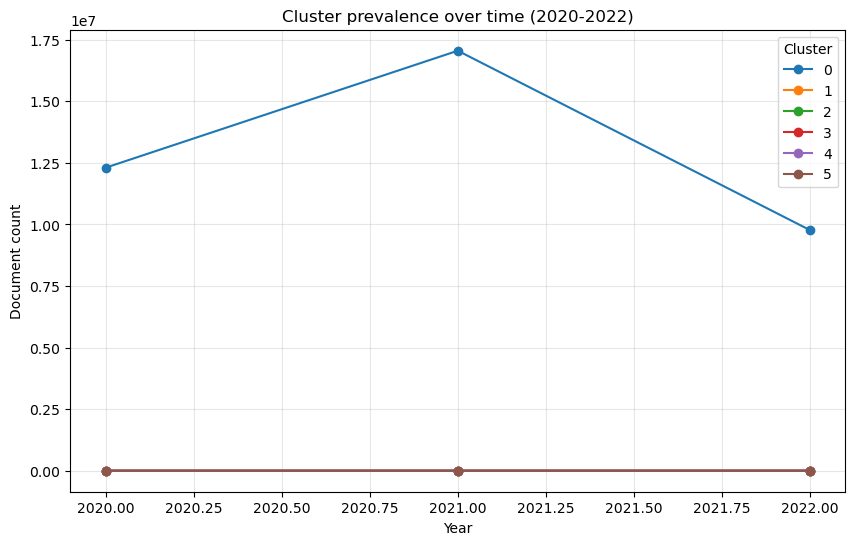


Document counts by year and cluster:
cluster           0      1     2      3     4     5
year                                               
2020     12303020.0    0.0  34.0  423.0  23.0  23.0
2021     17055316.0  103.0   0.0   13.0   0.0   0.0
2022      9768691.0    0.0   0.0    3.0   0.0   0.0


In [7]:
import pandas as pd
import matplotlib.pyplot as plt

trend = (clusteredDF
    .groupBy("year","cluster")
    .count()
    .orderBy("year", "cluster")
    .toPandas())

trend_pivot = trend.pivot(index="year", columns="cluster", values="count").fillna(0)

trend_pivot.plot(kind="line", marker="o", figsize=(10, 6))
plt.title("Cluster prevalence over time (2020-2022)")
plt.xlabel("Year")
plt.ylabel("Document count")
plt.legend(title="Cluster")
plt.grid(True, alpha=0.3)
plt.show()

# Show the actual counts
print("\nDocument counts by year and cluster:")
print(trend_pivot)

In [8]:
clusteredDF.printSchema()

root
 |-- doc_id: string (nullable = true)
 |-- doc_type: string (nullable = true)
 |-- author: string (nullable = true)
 |-- created_ts: timestamp (nullable = true)
 |-- year: integer (nullable = true)
 |-- quarter: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- months_since_start: double (nullable = true)
 |-- score: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- features_tfidf: vector (nullable = true)
 |-- pcaFeatures: vector (nullable = true)
 |-- cluster: integer (nullable = true)



In [27]:
cleanDF.printSchema()

root
 |-- doc_id: string (nullable = true)
 |-- doc_type: string (nullable = false)
 |-- author: string (nullable = true)
 |-- created_ts: timestamp (nullable = true)
 |-- score: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- text: string (nullable = true)
 |-- year: integer (nullable = true)
 |-- quarter: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- months_since_start: double (nullable = true)
 |-- tokens: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- tokens_clean_temp: array (nullable = true)
 |    |-- element: string (containsNull = true)
 |-- tokens_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)



In [44]:
# Select only what we need from each side (keeps Spark happy + fast)
clustered_subset = clusteredDF.select(
    "doc_id",
    "cluster",
    "year",
    "quarter",
    "month",
    "months_since_start"
)

clean_subset = cleanDF.select(
    "doc_id",
    "doc_type",
    "created_ts",
    "score",
    "num_comments",
    "text",
    "tokens_clean"
)

clustered_textDF = (
    clustered_subset
    .join(clean_subset, on="doc_id", how="inner")
)

In [45]:
clustered_textDF.printSchema()

root
 |-- doc_id: string (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- quarter: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- months_since_start: double (nullable = true)
 |-- doc_type: string (nullable = false)
 |-- created_ts: timestamp (nullable = true)
 |-- score: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- text: string (nullable = true)
 |-- tokens_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)



# Sentiment Analysis

In [2]:
clustered_textDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/clustered_text_data")

In [3]:
from pyspark.sql import functions as F
from pyspark.sql.types import DoubleType

In [4]:
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer

analyzer = SentimentIntensityAnalyzer()

@F.udf(returnType=DoubleType())
def vader_compound(text):
    if text is None:
        return None
    return float(analyzer.polarity_scores(text)["compound"])

In [5]:
textCol = "text"
dateCol = "created_ts"

sentDF = (clustered_textDF
          .withColumn("sent_compound", vader_compound(F.col(textCol))))

### Cluster -> Sentiment Profile

In [6]:
cluster_sent_summary = (
    sentDF
    .groupBy("cluster")
    .agg(
        F.count("*").alias("n_docs"),
        F.avg("sent_compound").alias("mean_sent"),
        F.stddev("sent_compound").alias("sd_sent"),
        F.expr("percentile_approx(sent_compound, 0.5)").alias("median_sent"),
        F.expr("percentile_approx(sent_compound, array(0.25, 0.75))").alias("iqr_sent")
    )
    .orderBy("cluster")
)

cluster_sent_summary.show(truncate=False)

+-------+--------+----------------------+-------------------+-----------+-----------------+
|cluster|n_docs  |mean_sent             |sd_sent            |median_sent|iqr_sent         |
+-------+--------+----------------------+-------------------+-----------+-----------------+
|0      |39127027|0.051134661225323404  |0.4404227980396108 |0.0        |[-0.2263, 0.4019]|
|1      |103     |0.005894174757281552  |0.13397273487998992|0.0        |[0.0, 0.0]       |
|2      |34      |0.00595               |0.03469416377432954|0.0        |[0.0, 0.0]       |
|3      |439     |-0.0013599088838268786|0.11030785412322289|0.0        |[0.0, 0.0]       |
|4      |23      |-0.04155652173913043  |0.21045847749850358|-0.1275    |[-0.1275, 5.0E-4]|
|5      |23      |0.0                   |0.0                |0.0        |[0.0, 0.0]       |
+-------+--------+----------------------+-------------------+-----------+-----------------+



## Interpretation: Sentiment by Cluster (VADER)

Across clusters, the **median sentiment is 0.0 for most cluster**, implying that most documents are neutral by VADER’s compound score. 

Cluster 0 (the dominant cluster) has a slightly positive mean sentiment (**0.0511**) with a large spread (**sd ≈ 0.4404**), consistent with a high-volume mix of hype, jokes, panic, and neutral chatter. 

The small clusters have near-zero means (≈ 0.0) and much smaller standard deviations, but given their tiny sample sizes (e.g., **n=23–439**), these sentiment estimates are **not stable enough** to generalize from. 


### Sentiment over time within each cluster

In [39]:
daily_cluster_sent = (
    sentDF
    .withColumn("day", F.to_date(F.col(dateCol)))   # if already a date, you can skip to_date
    .groupBy("day", "cluster")
    .agg(
        F.count("*").alias("n_docs"),
        F.avg("sent_compound").alias("mean_sent")
    )
    .orderBy("day", "cluster")
)

daily_cluster_sent.show(20, truncate=False)

[Stage 60:=======================================================>(66 + 1) / 67]

+----------+-------+------+----------------------+
|day       |cluster|n_docs|mean_sent             |
+----------+-------+------+----------------------+
|2020-01-01|0      |3793  |0.07917772211969418   |
|2020-01-02|0      |11582 |0.04300357451217408   |
|2020-01-03|0      |9885  |0.009263621648963076  |
|2020-01-04|0      |3854  |0.05878004670472235   |
|2020-01-05|0      |5266  |0.019892385112039494  |
|2020-01-06|0      |9187  |0.0444027865462066    |
|2020-01-07|0      |14275 |-0.0026643292469351967|
|2020-01-08|0      |13396 |0.027566004777545543  |
|2020-01-09|0      |11779 |0.057431233551235236  |
|2020-01-10|0      |9746  |0.050935922429714765  |
|2020-01-11|0      |4419  |0.06932731387191672   |
|2020-01-12|0      |5321  |0.08519755685021614   |
|2020-01-13|0      |12322 |0.06402962993020614   |
|2020-01-14|0      |14180 |0.05359500705218616   |
|2020-01-15|0      |13943 |0.050369124291759305  |
|2020-01-16|0      |13672 |0.06541122001170276   |
|2020-01-17|0      |10787 |0.07

## Post-hoc semantic characterization

In [47]:
clustered_textDF.printSchema()

root
 |-- doc_id: string (nullable = true)
 |-- cluster: integer (nullable = true)
 |-- year: integer (nullable = true)
 |-- quarter: integer (nullable = true)
 |-- month: integer (nullable = true)
 |-- months_since_start: double (nullable = true)
 |-- doc_type: string (nullable = false)
 |-- created_ts: timestamp (nullable = true)
 |-- score: long (nullable = true)
 |-- num_comments: long (nullable = true)
 |-- text: string (nullable = true)
 |-- tokens_clean: array (nullable = true)
 |    |-- element: string (containsNull = true)



In [49]:
clustered_textDF.write.mode("overwrite").parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/clustered_text_data")

In [2]:
clustered_textDF = spark.read.parquet("/project/macs40123/amritap1/macs-40123-amritapathak1/project/analysis/clustered_text_data").select("cluster", "tokens_clean").cache()
clustered_textDF.count()

25/12/12 15:00:20 WARN MemoryStore: Not enough space to cache rdd_6_27 in memory! (computed 123.4 MiB so far)
25/12/12 15:00:20 WARN BlockManager: Persisting block rdd_6_27 to disk instead.
25/12/12 15:00:21 WARN MemoryStore: Not enough space to cache rdd_6_36 in memory! (computed 31.9 MiB so far)
25/12/12 15:00:21 WARN BlockManager: Persisting block rdd_6_36 to disk instead.
25/12/12 15:00:21 WARN MemoryStore: Not enough space to cache rdd_6_35 in memory! (computed 31.8 MiB so far)
25/12/12 15:00:21 WARN BlockManager: Persisting block rdd_6_35 to disk instead.
25/12/12 15:00:21 WARN MemoryStore: Not enough space to cache rdd_6_38 in memory! (computed 31.7 MiB so far)
25/12/12 15:00:21 WARN MemoryStore: Not enough space to cache rdd_6_33 in memory! (computed 62.2 MiB so far)
25/12/12 15:00:21 WARN BlockManager: Persisting block rdd_6_38 to disk instead.
25/12/12 15:00:21 WARN BlockManager: Persisting block rdd_6_33 to disk instead.
25/12/12 15:00:21 WARN MemoryStore: Not enough space t

39127649

In [7]:
from pyspark.sql import functions as F
from pyspark.sql.window import Window

token_counts = (
    clustered_textDF
    .where(F.col("tokens_clean").isNotNull())
    .select("cluster", F.explode("tokens_clean").alias("token"))
    .where(F.length("token") >= 3)
    .groupBy("cluster", "token")
    .count()
)

w = Window.partitionBy("cluster").orderBy(F.desc("count"))
top_tokens = (
    token_counts
    .withColumn("rank", F.row_number().over(w))
    .where(F.col("rank") <= 30)
    .orderBy("cluster", "rank")
)

top_tokens.show(300, truncate=False)

[Stage 6:=======>                                                   (1 + 7) / 8]

+-------+-----+-------+----+
|cluster|token|count  |rank|
+-------+-----+-------+----+
|0      |ing  |4145333|1   |
|0      |like |3543761|2   |
|0      |buy  |2499793|3   |
|0      |get  |2462174|4   |
|0      |one  |2300063|5   |
|0      |stock|2239503|6   |
|0      |marke|2181976|7   |
|0      |money|2082084|8   |
|0      |think|2065782|9   |
|0      |going|1916907|10  |
|0      |peopl|1862834|11  |
|0      |share|1790459|12  |
|0      |every|1787205|13  |
|0      |calls|1764547|14  |
|0      |time |1667221|15  |
|0      |day  |1595852|16  |
|0      |good |1580808|17  |
|0      |gme  |1546638|18  |
|0      |short|1499448|19  |
|0      |becau|1424919|20  |
|0      |shit |1421568|21  |
|0      |back |1416513|22  |
|0      |puts |1389401|23  |
|0      |make |1385842|24  |
|0      |know |1371882|25  |
|0      |sell |1365728|26  |
|0      |still|1345657|27  |
|0      |thing|1344285|28  |
|0      |today|1339911|29  |
|0      |price|1335566|30  |
|1      |amzn |78732  |1   |
|1      |tsla 

In [6]:
from pyspark.ml.feature import NGram

ng = NGram(n=2, inputCol="tokens_clean", outputCol="bigrams")
tmp2 = ng.transform(clustered_textDF).select("cluster", "bigrams")

bigram_counts = (
    tmp2
    .select("cluster", F.explode("bigrams").alias("bigram"))
    .groupBy("cluster", "bigram")
    .count()
)

w2 = Window.partitionBy("cluster").orderBy(F.desc("count"))
top_bigrams = (
    bigram_counts
    .withColumn("rank", F.row_number().over(w2))
    .where(F.col("rank") <= 25)
    .orderBy("cluster", "rank")
)

top_bigrams.show(300, truncate=False)

25/12/12 15:02:37 WARN MemoryStore: Not enough space to cache rdd_6_4 in memory! (computed 124.2 MiB so far)
25/12/12 15:02:37 WARN MemoryStore: Not enough space to cache rdd_6_1 in memory! (computed 124.1 MiB so far)
25/12/12 15:03:01 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:02 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValueBatch. Will not spill but return 0.
25/12/12 15:03:03 WARN RowBasedKeyValueBatch: Calling spill() on RowBasedKeyValu

+-------+-----------+------+----+
|cluster|bigram     |count |rank|
+-------+-----------+------+----+
|0      |tomor row  |823297|1   |
|0      |img emote  |689050|2   |
|0      |actua lly  |636829|3   |
|0      |proba bly  |616077|4   |
|0      |every one  |605007|5   |
|0      |somet hing |602262|6   |
|0      |earni ngs  |552917|7   |
|0      |liter ally |439454|8   |
|0      |anyth ing  |428944|9   |
|0      |every thing|399627|10  |
|0      |retar ded  |373565|11  |
|0      |robin hood |355654|12  |
|0      |yeste rday |354556|13  |
|0      |submi ssion|340222|14  |
|0      |posit ion  |326376|15  |
|0      |posit ions |321345|16  |
|0      |compa nies |309653|17  |
|0      |think ing  |307171|18  |
|0      |comme nts  |299057|19  |
|0      |walls treet|298153|20  |
|0      |treet bets |266600|21  |
|0      |inter est  |265961|22  |
|0      |infla tion |265147|23  |
|0      |finan cial |248694|24  |
|0      |remem ber  |236915|25  |
|1      |amzn amzn  |78619 |1   |
|1      |amzn 

In [8]:
# Collect top tokens per cluster into a list
top_tokens_list = (
    top_tokens
    .groupBy("cluster")
    .agg(F.collect_list(F.struct(F.col("rank"), F.col("token"))).alias("tok_list"))
)

# Keep just tokens in rank order (simple)
top_tokens_clean = (
    top_tokens_list
    .withColumn("top_tokens",
                F.expr("transform(array_sort(tok_list), x -> x.token)"))
    .select("cluster", "top_tokens")
)

final_cluster_profile = (
    cluster_sent_summary
    .join(top_tokens_clean, on="cluster", how="left")
    .orderBy("cluster")
)

final_cluster_profile.show(truncate=False)

[Stage 30:>                                                         (0 + 1) / 1]

+-------+--------+----------------------+-------------------+-----------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|cluster|n_docs  |mean_sent             |sd_sent            |median_sent|iqr_sent         |top_tokens                                                                                                                                                                                           |
+-------+--------+----------------------+-------------------+-----------+-----------------+-----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------+
|0      |39127027|0.051134661225323404  |0.4404227980396108 |0.0        |[-0.2263, 0.4019]|[ing, like, buy, get, one, stock, marke

## Methodological Note (Important Limitation)

Because Cluster 0 contains essentially the entire dataset (39M+ documents), the clustering solution behaves less like a set of balanced behavioral segments and more like **one dominant discourse cluster plus a small number of sparse edge clusters**.

As a result, Cluster 0 should be interpreted as the baseline r/wallstreetbets discourse environment, capturing general conversational, emotional, and trading-related language.

The remaining clusters are best understood as **special-case regimes**,often anchored by specific tickers or thread structures, rather than as equally sized or directly comparable behavioral archetypes.
